# 3.0 Experimento principal

Este notebook es el esqueleto del experimento final. La idea es ejecutarlo en una
máquina con más recursos, por ejemplo Google Colab, sin mezclarlo con los notebooks
exploratorios anteriores.

Ruta final:

1. cargar muestra simulada GUMS/GOG con verdad conocida;
2. preparar variables observadas y cortes de calidad;
3. construir grilla fija del CMD independiente de la muestra de evaluación;
4. ajustar Modelo 0 (solo paralaje, prior uniforme truncado);
5. ajustar Modelo 1 (CMD marginalizado, pesos flexibles);
6. ajustar Modelo 2 (CMD marginalizado + escala global lambda);
7. validar VI con métricas contra verdad simulada y NUTS en submuestra;
8. guardar trazas ArviZ y tablas listas para el Capítulo IV.

## Instalación en Colab

In [ ]:
!pip install -q "project[colab] @ git+https://github.com/IsaacMercado/estimacion-paralajes.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

import arviz as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import pytensor
import pytensor.tensor as pt
import sympy as sp
from pytensor.compile.mode import Mode
from pytensor.link.jax import JAXLinker

from project.utils import DATA_RAW_DIR, MODELS_DIR
from project.utils.load import load_with_polars
from project.validation import evaluate_distance_posterior

pytensor.config.mode = Mode(linker=JAXLinker(), optimizer='fast_compile')

print('Devices:', jax.devices())
print('Backend:', jax.default_backend())
print("Count Devices:", jax.local_device_count())

Devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19), CpuDevice(id=20), CpuDevice(id=21), CpuDevice(id=22), CpuDevice(id=23), CpuDevice(id=24), CpuDevice(id=25), CpuDevice(id=26), CpuDevice(id=27), CpuDevice(id=28), CpuDevice(id=29), CpuDevice(id=30), CpuDevice(id=31), CpuDevice(id=32), CpuDevice(id=33), CpuDevice(id=34), CpuDevice(id=35), CpuDevice(id=36), CpuDevice(id=37), CpuDevice(id=38), CpuDevice(id=39), CpuDevice(id=40), CpuDevice(id=41), CpuDevice(id=42), CpuDevice(id=43), CpuDevice(id=44), CpuDevice(id=45), CpuDevice(id=46), CpuDevice(id=47), CpuDevice(id=48), CpuDevice(id=49), CpuDevice(id=50), CpuDevice(id=51), CpuDevice(id=52), CpuDevice(id=53), CpuDevice(id=54), CpuDevice(

In [ ]:
SIMULATION_FILENAME = "simulation_data.ecsv"
FITZ19_FILENAME = "Fitz19_EDR3_MainSequence.csv"
SIMULATION_FILE = DATA_RAW_DIR / SIMULATION_FILENAME
FITZ19_FILE = DATA_RAW_DIR / FITZ19_FILENAME
SEED = 2026

In [ ]:
try:
  from google.colab import drive
  import shutil

  path_drive = Path("/content/drive")
  drive.mount(path_drive.as_posix())

  path_simulation_file = path_drive / "MyDrive" / SIMULATION_FILENAME
  if not path_simulation_file.exists():
      raise FileNotFoundError(f"File {path_simulation_file} not found.")

  shutil.copyfile(path_simulation_file, SIMULATION_FILE)

  path_fitz19_file = path_drive / "MyDrive" / FITZ19_FILENAME
  if not path_fitz19_file.exists():
      raise FileNotFoundError(f"File {path_fitz19_file} not found.")

  shutil.copyfile(path_fitz19_file, FITZ19_FILE)

except NotImplementedError:
    !pip install -q gdown
    !gdown "https://drive.google.com/uc?id=1tQk1hUPhQ3VPfo-PXQD-_ZVUiF_vPMh9" -O $SIMULATION_FILE
    !gdown "https://drive.google.com/uc?id=1XkUmmr1F8oKABP1Eou3lbC4jCsWEpkum" -O $FITZ19_FILE

except ModuleNotFoundError:
  print("Not running in Colab.")

Mounted at /content/drive


## Preparación de datos

Reemplazar esta función con la lectura final de la muestra simulada. Es importante
guardar y conservar `source_id` para verificar que la traza y la tabla estén en el
mismo orden.

### Fórmulas de extinción estelar

In [ ]:
teff, teff_error, a0, a0_error, *a = sp.symbols(
    'teff teff_error '
    'A0 A0_error '
    'a1 a2 a3 a4 a5 a6 a7 a8 a9 a10'
)
X = teff / 5040
k_m = (
    a[0] +
    a[1]*X +
    a[2]*X**2 +
    a[3]*X**3 +
    a[4]*a0 +
    a[5]*a0**2 +
    a[6]*a0**3 +
    a[7]*a0*X +
    a[8]*a0*X**2 +
    a[9]*X*a0**2
)
A_m = k_m * a0
k_m_error = sp.sqrt(
    (sp.diff(A_m, teff)*teff_error)**2 +
    (sp.diff(A_m, a0)*a0_error)**2
)


def extinction_m(coeff: pl.DataFrame, color: str):
  k_m_name = f"k{color.upper()}"

  values = (
      coeff.filter(pl.col("Kname") == k_m_name)
      .select(pl.all().exclude("Kname"))
  ).row(0)

  expr_km = sp.lambdify((teff, a0, *a), k_m)(
      pl.col("teff"),
      pl.col("a0"),
      *values,
  )
  expr_am_error = sp.lambdify((teff, a0, teff_error, a0_error, *a), k_m_error)(
      pl.col("teff"),
      pl.col("a0"),
      pl.col("teff_error") ,
      pl.col("a0_error"),
      *values
  )

  return (
      (pl.col("a0")*expr_km).alias(f"a{color.lower()}"),
      expr_am_error.alias(f"a{color.lower()}_error")
  )

### Lectura de datos

In [ ]:
def flux_to_mag_sigma(flux_col: str, flux_error_col: str) -> pl.Expr:
    snr = pl.col(flux_col) / pl.col(flux_error_col)
    return (2.5 / np.log(10.0) / snr).cast(pl.Float32)


def load_simulated_catalog(path: Path) -> pl.DataFrame:
    df, _columns = load_with_polars(path)
    return (
        df
        .drop_nans()
        .drop_nulls()
        .with_columns(
            (pl.col("parallax") / pl.col("parallax_error")).alias("parallax_snr"),
            (pl.col("phot_bp_mean_mag") - pl.col("phot_rp_mean_mag")).alias("color_obs"),
        )
        .with_columns(
            flux_to_mag_sigma("phot_g_mean_flux", "phot_g_mean_flux_error").alias("sigma_g_mag"),
            flux_to_mag_sigma("phot_bp_mean_flux", "phot_bp_mean_flux_error").alias("sigma_bp_mag"),
            flux_to_mag_sigma("phot_rp_mean_flux", "phot_rp_mean_flux_error").alias("sigma_rp_mag"),
        )
        .with_columns(
            (
                (pl.col("sigma_bp_mag").pow(2) + pl.col("sigma_rp_mag").pow(2))
                .sqrt()
                .alias("sigma_color")
            ),
            pl.col("parallax_snr").cut(
                breaks=[3, 5, 10],
                labels=["1-3", "3-5", "5-10", ">10"]
            ).alias("stratum"),
        )
    )


def select_simulation_sample(df: pl.DataFrame, n_stars: int, seed: int) -> pd.DataFrame:
    if df.height > n_stars:
        df = df.sample(n=n_stars, seed=seed)
    return df.sort("source_id")


def load_fitz19_catalog(path: Path) -> pl.DataFrame:
    return (
        pl.read_csv(path)
        .filter(pl.col("Xname") == "TeffNorm")
        .filter(pl.col("Kname").is_in(("kRP", "kBP", "kG")))
        .select(pl.all().exclude("Xname"))
    )

In [ ]:
coeff = load_fitz19_catalog(DATA_RAW_DIR / FITZ19_FILENAME)
catalog = load_simulated_catalog(SIMULATION_FILE).with_columns([
    *extinction_m(coeff, "g"),
    *extinction_m(coeff, "bp"),
    *extinction_m(coeff, "rp"),
])
catalog.head()

source_id,ra,dec,barycentric_distance,mag_g,mag_bp,mag_rp,ra_sim,ra_error,dec_sim,dec_error,parallax,parallax_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,teff,teff_error,a0,a0_error,parallax_snr,color_obs,sigma_g_mag,sigma_bp_mag,sigma_rp_mag,sigma_color,stratum,ag,ag_error,abp,abp_error,arp,arp_error
i64,f64,f64,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,enum,f32,f32,f32,f32,f32,f32
1729382514608308297,266.485879,-28.924615,5703.887207,15.840521,16.262024,15.211703,266.485879,0.052013,-28.924619,0.052781,0.203568,0.075509,8060.158203,6.16043,15.842641,4068.377197,3.397017,16.263247,5856.459473,5.998731,15.210512,10592.537109,0.0,2.415923,0.0,2.69593,1.052734,0.00083,0.000907,0.001112,0.001435,"""1-3""",2.261103,0.0,2.66775,0.0,1.588,0.0
1729382514608309151,266.490112,-28.922073,1327.904663,17.343899,18.074467,16.473137,266.490102,0.106769,-28.922081,0.108343,0.654801,0.154997,135.595551,0.2129,20.277887,28.787418,0.507285,21.638794,1798.994629,47.193829,16.492025,5546.257324,0.0,1.793379,0.0,4.224599,5.146769,0.001705,0.019133,0.028483,0.034312,"""3-5""",1.468504,0.0,1.860162,0.0,1.139602,0.0
1729382514608309157,266.487797,-28.919457,2425.311035,19.013836,19.919689,18.033987,266.487796,0.36829,-28.919457,0.373711,1.062139,0.534636,193.712372,0.254324,19.890606,140.034149,1.87882,19.921215,423.660431,8.362626,18.062056,5559.04248,0.0,2.534543,0.0,1.986659,1.859159,0.001425,0.014567,0.021431,0.025913,"""1-3""",2.034306,0.0,2.603254,0.0,1.599415,0.0
1729382514608310001,266.486195,-28.913284,7530.526855,20.165361,21.177307,19.130116,266.48619,1.514585,-28.913302,1.536785,3.376858,2.198548,149.80603,0.347064,20.169678,45.290649,1.151855,21.146778,152.875778,5.764545,19.168753,5610.47998,0.0,2.924928,0.0,1.535949,1.978025,0.002515,0.027613,0.04094,0.049382,"""1-3""",2.329338,0.0,2.992984,0.0,1.840337,0.0
1729382514608310094,266.488103,-28.916805,7646.353516,18.036472,19.504309,16.818388,266.488095,0.167151,-28.916817,0.169607,0.342175,0.242643,1067.234619,0.896529,18.037849,205.832779,0.625357,19.503014,1328.136963,5.87102,16.821493,4549.880371,0.0,3.869021,0.0,1.4102,2.68152,0.000912,0.003299,0.004799,0.005824,"""1-3""",2.821571,0.0,3.802994,0.0,2.356046,0.0


In [ ]:
catalog.group_by("stratum").agg(
    pl.col("parallax_snr").count().alias("count"),
    pl.col("parallax_snr").mean().alias("mean"),
    pl.col("parallax_snr").std().alias("std"),
    pl.col("parallax_snr").min().alias("min"),
    pl.col("parallax_snr").max().alias("max"),
).sort("stratum")

stratum,count,mean,std,min,max
enum,u32,f32,f32,f32,f32
"""1-3""",1685826,1.737169,0.531606,1.0,2.999998
"""3-5""",351021,3.818312,0.568668,3.000001,4.999993
"""5-10""",260817,6.94566,1.401959,5.000045,9.999958
""">10""",202336,22.732235,22.879391,10.000004,1148.494263


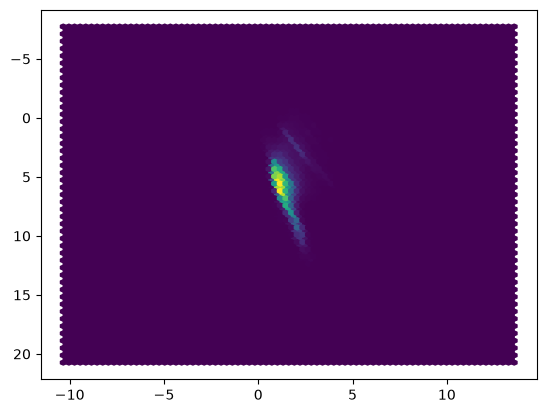

In [ ]:
M_obs = catalog["phot_g_mean_mag"] - 5*np.log10(catalog["barycentric_distance"]) + 5  # ojo unidades pc
plt.hexbin(catalog["color_obs"], M_obs, gridsize=80)
plt.gca().invert_yaxis()

In [ ]:
catalog.select(
    "teff_error",
    "a0_error",
    "ag_error",
    "abp_error",
    "arp_error",
).sum()

teff_error,a0_error,ag_error,abp_error,arp_error
f32,f32,f32,f32,f32
0.0,0.0,0.0,0.0,0.0


## Grilla fija del CMD

No construir esta grilla con cuantiles de la misma muestra evaluada. Aquí se usa un
rango fijo amplio para Gaia. Ajustar resolución según recursos disponibles.

In [ ]:
def compute_oracle_weights(df: pl.DataFrame, grid: dict) -> np.ndarray:
    # CORRECCIÓN: Eliminamos el * 1e3 porque barycentric_distance ya está en parsecs
    M_G_true, color_true = df.select(
        (pl.col("mag_g") - 5.0 * pl.col("barycentric_distance").log10() + 5.0).alias("M_G_true"),
        (pl.col("mag_bp") - pl.col("mag_rp")).alias("color_true"),
    ).to_jax().T

    counts, _, _ = np.histogram2d(
        color_true, # El orden en histogram2d es [x, y]
        M_G_true,
        bins=[grid["color_edges"], grid["abs_edges"]],
        density=True
    )
    # Transponemos para que coincida con el ravel() de mu_color/mu_abs_mag
    w_oracle = counts.T.ravel()
    w_oracle = w_oracle / (w_oracle.sum() + 1e-12)
    return w_oracle


def build_fixed_cmd_grid(
    color_range=(-0.5, 9.0),
    abs_mag_range=(-4.0, 16.0),
    n_color=25,
    n_abs_mag=35,
):
    color_edges = np.linspace(color_range[0], color_range[1], n_color + 1)
    mag_edges = np.linspace(abs_mag_range[0], abs_mag_range[1], n_abs_mag + 1)
    color_step = color_edges[1] - color_edges[0]
    mag_step = mag_edges[1] - mag_edges[0]
    color_centers = 0.5 * (color_edges[:-1] + color_edges[1:])
    mag_centers = 0.5 * (mag_edges[:-1] + mag_edges[1:])
    grid_color, grid_mag = np.meshgrid(color_centers, mag_centers, indexing="xy")
    return {
        "mu_color": grid_color.ravel(),
        "mu_abs_mag": grid_mag.ravel(),
        "sigma_color_kernel": np.full(grid_color.size, color_step),
        "sigma_abs_mag_kernel": np.full(grid_color.size, mag_step),
        "color_edges": color_edges,
        "abs_edges": mag_edges,
        "shape": grid_mag.shape,
    }

def prepare_model_data(df: pl.DataFrame, grid: dict, r_min=10.0, r_max=20_000.0) -> dict:
    w_oracle = compute_oracle_weights(df, grid)
    return {
        "parallax": df["parallax"].to_numpy(),
        "parallax_error": df["parallax_error"].to_numpy(),

        # CORRECCIÓN: Restamos la extinción Ag para obtener la magnitud observada
        "m_obs": df["phot_g_mean_mag"].to_numpy() - df["ag"].to_numpy(),
        # CORRECCIÓN: Ajustamos el color observado para la extinción
        "color_obs": df["color_obs"].to_numpy() - df["abp"].to_numpy() + df["arp"].to_numpy(),

        "sigma_m": df["sigma_g_mag"].to_numpy(),
        "sigma_color": df["sigma_color"].to_numpy(),

        "r_min": float(r_min),
        "r_max": float(r_max),
        "oracle_weights": w_oracle,
        **grid,
    }

## Datos

In [ ]:
N_NUTS = 3000
sub_sample = catalog.sample(n=N_NUTS, seed=SEED + 100).sort("source_id")

grid = build_fixed_cmd_grid(
    n_color=50,
    n_abs_mag=60,
    color_range=(-0.5, 9.0),
    abs_mag_range=(-4.0, 16.0),
)

model_data_np = prepare_model_data(sub_sample, grid, r_min=10.0, r_max=20_000.0)
model_data = {
    key: np.asarray(value) if not isinstance(value, float) else value
    for key, value in model_data_np.items()
}

n_stars = model_data['parallax'].size
n_kernels = model_data['mu_abs_mag'].size

## Modelos PyMC

In [ ]:
coords = {"star": np.arange(n_stars)}

with pm.Model() as model_0:
    parallax = pm.Data(
        "parallax",
        model_data["parallax"],
        dims="star",
    )
    parallax_error = pm.Data(
        "parallax_error",
        model_data["parallax_error"],
        dims="star",
    )

    distance_pc = pm.Uniform(
        "distance_pc",
        lower=model_data['r_min'],
        upper=model_data['r_max'],
        # initval=model_data["distance_init"],
        dims="star",
    )
    pm.Normal(
        "parallax_like",
        mu=1000.0 / distance_pc,
        sigma=parallax_error,
        observed=parallax,
        dims="star",
    )

    idata_0 = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        core=2,
        random_seed=SEED + 200,
    )



Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
idata_0.to_netcdf(MODELS_DIR / "modelo_0_nuts.nc")

PosixPath('/content/models/modelo_0_nuts.nc')

In [ ]:
coords = {
    "star": np.arange(n_stars),
    "kernel": np.arange(n_kernels),
}

with pm.Model(coords=coords) as model_1:
    # Data principal (usando pm.Data para flexibilidad)
    parallax = pm.Data("parallax", model_data["parallax"], dims="star")
    parallax_error = pm.Data("parallax_error", model_data["parallax_error"], dims="star")
    m_obs = pm.Data("m_obs", model_data["m_obs"], dims="star")
    sigma_m = pm.Data("sigma_m", model_data["sigma_m"], dims="star")
    color_obs = pm.Data("color_obs", model_data["color_obs"], dims="star")
    sigma_color = pm.Data("sigma_color", model_data["sigma_color"], dims="star")

    # Grilla fija como tensores constantes
    mu_abs_mag_g = pt.as_tensor_variable(model_data['mu_abs_mag'])
    mu_color_g = pt.as_tensor_variable(model_data['mu_color'])
    sigma_abs_kernel_g = pt.as_tensor_variable(model_data['sigma_abs_mag_kernel'])
    sigma_color_kernel_g = pt.as_tensor_variable(model_data['sigma_color_kernel'])

    # Priors
    weights = pm.Dirichlet("weights", a=np.ones(n_kernels), dims="kernel")
    # Variable discreta que requiere Gibbs
    b = pm.Categorical("bins", p=weights, dims="star")
    # Variable continua que requiere NUTS (GPU)
    distance_pc = pm.Uniform("distance_pc", lower=model_data['r_min'], upper=model_data['r_max'], dims="star")

    # Likelihoods
    mu_m = mu_abs_mag_g[b] + 5.0 * pt.log10(distance_pc) - 5.0
    sigma_m_total = pt.sqrt(sigma_m**2 + sigma_abs_kernel_g[b]**2)
    sigma_color_total = pt.sqrt(sigma_color**2 + sigma_color_kernel_g[b]**2)

    pm.Normal("parallax_like", mu=1000.0 / distance_pc, sigma=parallax_error, observed=parallax, dims="star")
    pm.Normal("m_like", mu=mu_m, sigma=sigma_m_total, observed=m_obs, dims="star")
    pm.Normal("color_like", mu=mu_color_g[b], sigma=sigma_color_total, observed=color_obs, dims="star")

    # Definición explícita de pasos para el muestreador híbrido
    # 1. Gibbs para las variables categóricas (bins)
    step_gibbs = pm.CategoricalGibbsMetropolis(vars=[b])

    # 2. NUTS para las variables continuas (weights, distance_pc)
    step_nuts = pm.NUTS(vars=[weights, distance_pc])

    # Muestreo: No usamos nuts_sampler="numpyro" aquí porque es incompatible con steps manuales.
    # PyMC usará su implementación de NUTS estándar.
    idata_1 = pm.sample(
        draws=1000,
        tune=500,
        step=[step_gibbs, step_nuts],
        random_seed=SEED + 210,
        chains=2,
        cores=1,
    )


 Progress                        Draw   Divergences   Step size   Grad evals   Speed         Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   1500   223           0.011       217          3.37 s/draw   1:24:11   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━   1388   204           0.010       354          7.05 s/draw   2:43:07   0:06:47

In [ ]:
idata_1.to_netcdf(MODELS_DIR / "modelo_1_nuts.nc")

PosixPath('/content/models/modelo_1_nuts.nc')

In [ ]:
coords = {
    "star": np.arange(n_stars),
    "kernel": np.arange(n_kernels),
}

with pm.Model(coords=coords) as model_2:
    # Data principal (usando pm.Data para flexibilidad)
    parallax = pm.Data("parallax", model_data["parallax"], dims="star")
    parallax_error = pm.Data("parallax_error", model_data["parallax_error"], dims="star")
    m_obs = pm.Data("m_obs", model_data["m_obs"], dims="star")
    sigma_m = pm.Data("sigma_m", model_data["sigma_m"], dims="star")
    color_obs = pm.Data("color_obs", model_data["color_obs"], dims="star")
    sigma_color = pm.Data("sigma_color", model_data["sigma_color"], dims="star")

    # Grilla fija como tensores constantes
    mu_abs_mag_g = pt.as_tensor_variable(model_data['mu_abs_mag'])
    mu_color_g = pt.as_tensor_variable(model_data['mu_color'])
    sigma_abs_kernel_g = pt.as_tensor_variable(model_data['sigma_abs_mag_kernel'])
    sigma_color_kernel_g = pt.as_tensor_variable(model_data['sigma_color_kernel'])

    # Priors
    weights = pm.Dirichlet("weights", a=np.ones(n_kernels), dims="kernel")
    # Variable discreta que requiere Gibbs
    b = pm.Categorical("bins", p=weights, dims="star")
    # Variable continua que requiere NUTS (GPU)
    distance_pc = pm.Uniform("distance_pc", lower=model_data['r_min'], upper=model_data['r_max'], dims="star")
    lambda_cmd = pm.LogNormal("lambda_cmd", mu=0.0, sigma=0.25)

    # Likelihoods
    mu_m = mu_abs_mag_g[b] + 5.0 * pt.log10(distance_pc) - 5.0
    sigma_m_total = pt.sqrt(sigma_m**2 + (sigma_abs_kernel_g[b] * lambda_cmd)**2)
    sigma_color_total = pt.sqrt(sigma_color**2 + (sigma_color_kernel_g[b] * lambda_cmd)**2)

    pm.Normal("parallax_like", mu=1000.0 / distance_pc, sigma=parallax_error, observed=parallax, dims="star")
    pm.Normal("m_like", mu=mu_m, sigma=sigma_m_total, observed=m_obs, dims="star")
    pm.Normal("color_like", mu=mu_color_g[b], sigma=sigma_color_total, observed=color_obs, dims="star")

    # Definición explícita de pasos para el muestreador híbrido
    # 1. Gibbs para las variables categóricas (bins)
    step_gibbs = pm.CategoricalGibbsMetropolis(vars=[b])

    # 2. NUTS para las variables continuas (weights, distance_pc)
    step_nuts = pm.NUTS(vars=[weights, distance_pc, lambda_cmd])

    # Muestreo: No usamos nuts_sampler="numpyro" aquí porque es incompatible con steps manuales.
    # PyMC usará su implementación de NUTS estándar.
    idata_2 = pm.sample(
        draws=1000,
        tune=500,
        step=[step_gibbs, step_nuts],
        random_seed=SEED,
        chains=2,
        cores=1,
    )


Output()

ERROR:pymc.stats.convergence:There were 521 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
idata_2.to_netcdf(MODELS_DIR / "modelo_2_nuts.nc")

if "path_drive" in globals():
    idata_2.to_netcdf(path_drive / "MyDrive" / "modelo_2_nuts.nc")

## Ejecución final

Descomentar y ajustar `N_STARS` cuando se ejecute en Colab.

### Muestreo MCMC (NUTS) en submuestra
Ejecutamos NUTS para obtener la posterior exacta en un subconjunto de los datos y validar los resultados de VI.

In [ ]:
true_dist_nuts = sub_sample["barycentric_distance"].to_numpy()
metrics_nuts0 = evaluate_distance_posterior(idata_0, true_dist_nuts, variable="distance_pc")
metrics_nuts1 = evaluate_distance_posterior(idata_1, true_dist_nuts, variable="distance_pc")
metrics_nuts2 = evaluate_distance_posterior(idata_2, true_dist_nuts, variable="distance_pc")

metrics_nuts0, metrics_nuts1, metrics_nuts2

(SimulationMetrics(variable='distance_pc', n=3000, rmse=3870.4625107767743, mean_bias=2608.313109286095, mean_relative_bias=1.080927800019281, coverage_68=0.7296666666666667, coverage_95=0.9666666666666667, mean_width_68=8788.30359709514, mean_width_95=13304.797450784261, median_width_95=17182.8829945182),
 SimulationMetrics(variable='distance_pc', n=3000, rmse=5788.891551046223, mean_bias=3848.7002995024113, mean_relative_bias=1.7858466171941334, coverage_68=0.435, coverage_95=0.6036666666666667, mean_width_68=6911.132800309219, mean_width_95=9998.610692361826, median_width_95=10777.943096515895),
 SimulationMetrics(variable='distance_pc', n=3000, rmse=4830.193379438486, mean_bias=2971.816951964844, mean_relative_bias=1.2601944699421546, coverage_68=0.48966666666666664, coverage_95=0.7563333333333333, mean_width_68=5736.3925489951025, mean_width_95=9610.60139016431, median_width_95=11701.696317648843))

### Visualización de Diagnósticos y Resultados
Generamos gráficos para evaluar la convergencia (diagnósticos) y la calidad de la predicción de distancias.

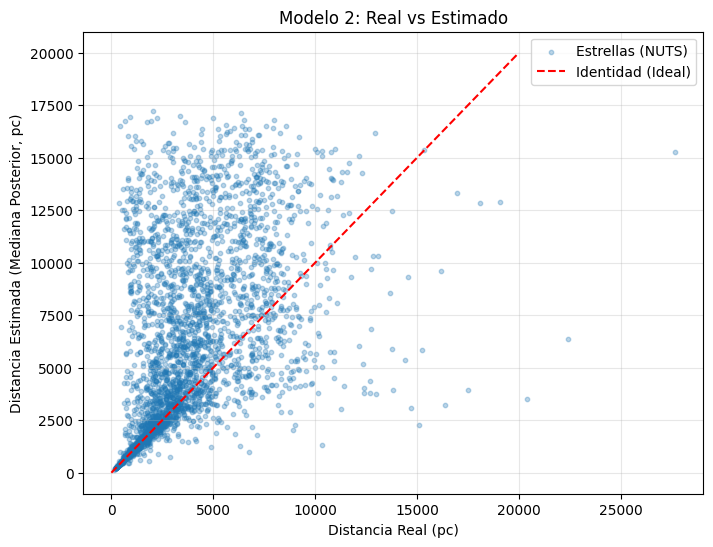

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparación Visual: Distancia Real vs Estimada (Modelo 2 NUTS)
plt.figure(figsize=(8, 6))
median_dist = idata_2.posterior["distance_pc"].median(dim=["chain", "draw"])

plt.scatter(true_dist_nuts, median_dist, alpha=0.3, s=10, label="Estrellas (NUTS)")
plt.plot([0, 20000], [0, 20000], color="red", linestyle="--", label="Identidad (Ideal)")
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Distancia Estimada (Mediana Posterior, pc)")
plt.title("Modelo 2: Real vs Estimado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

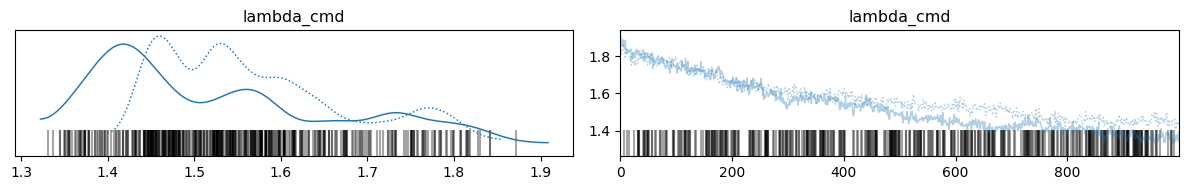

Diagnósticos para parámetros globales del Modelo 2:


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_cmd,1.551,0.126,1.352,1.801,0.075,0.022,3.0,11.0,2.0


In [ ]:
# 2. Diagnóstico de Convergencia para lambda_cmd (Modelo 2)
az.plot_trace(idata_2, var_names=["lambda_cmd"])
plt.tight_layout()
plt.show()

# 3. Resumen de diagnósticos (R-hat y ESS)
summary = az.summary(idata_2, var_names=["lambda_cmd"], hdi_prob=0.95)
print("Diagnósticos para parámetros globales del Modelo 2:")
display(summary.head(10))

### Comparación Final de Residuos
Graficamos el error relativo $(d_{est} - d_{true}) / d_{true}$ para ver el comportamiento del sesgo en función de la distancia real.

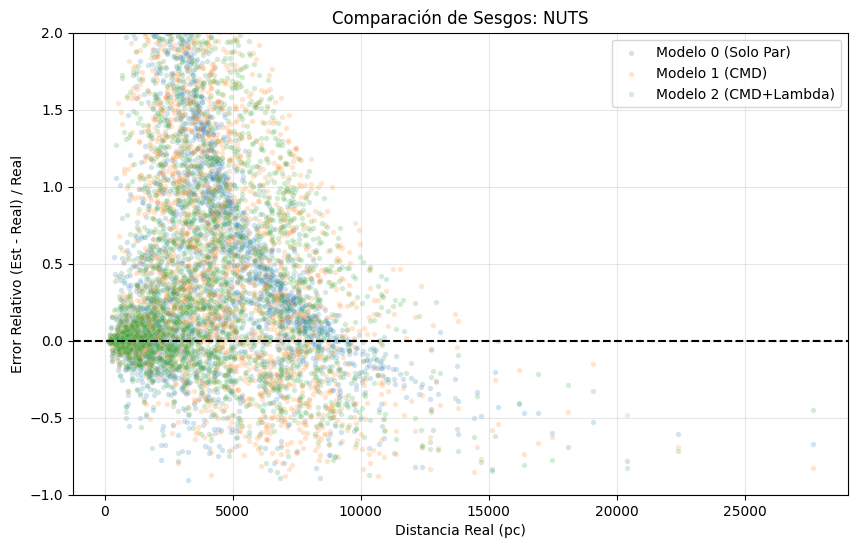

In [ ]:
def get_median_dist(idata):
    return idata.posterior["distance_pc"].median(dim=["chain", "draw"]).values

dists = {
    "Modelo 0 (Solo Par)": get_median_dist(idata_0),
    "Modelo 1 (CMD)": get_median_dist(idata_1),
    "Modelo 2 (CMD+Lambda)": get_median_dist(idata_2)
}

plt.figure(figsize=(10, 6))
for name, d_median in dists.items():
    residual_rel = (d_median - true_dist_nuts) / true_dist_nuts
    sns.scatterplot(x=true_dist_nuts, y=residual_rel, alpha=0.2, s=15, label=name)

plt.axhline(0, color="black", linestyle="--")
plt.ylim(-1, 2)
plt.xlabel("Distancia Real (pc)")
plt.ylabel("Error Relativo (Est - Real) / Real")
plt.title("Comparación de Sesgos: NUTS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()